# 🎓 Student Performance Analysis & Prediction
## GDGoC COMSATS WAH — DECODE: Data Science Bootcamp 2026
**Final Project | Deadline: March 27, 2026**

---
This notebook walks through the complete Data Science pipeline:
1. Load Data
2. Clean Data
3. EDA + Visualization
4. Feature Engineering + sklearn Pipeline
5. Model Building + Evaluation


## 📦 Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, OrdinalEncoder
)
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Nice plot defaults
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully ✅")


All libraries imported successfully ✅


---
## STEP 1 — Data Loading and First Look
We load the dataset and inspect it from multiple angles before touching anything.


In [2]:
# Load the dataset
# (Upload the Excel file to Colab or adjust the path as needed)
df = pd.read_excel('student_performance_dataset.xlsx')

print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")


DATASET SHAPE
Rows: 205, Columns: 14


In [3]:
print("=" * 60)
print("COLUMN NAMES & DATA TYPES (df.info())")
print("=" * 60)
df.info()


COLUMN NAMES & DATA TYPES (df.info())
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB


In [4]:
print("=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)
df.head()


FIRST 5 ROWS


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49


In [5]:
print("=" * 60)
print("LAST 5 ROWS")
print("=" * 60)
df.tail()


LAST 5 ROWS


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
200,185,Waseem,23,Male,Karachi,SE,Intermediate,85.0,7.0,6.0,9,NaN,No,46
201,38,Ayesha,23,Male,Wah,CS,Intermediate,71.0,4.0,9.0,13,87.0,Yes,51
202,68,AYESHA,24,Male,Lahore,CS,Bachelors,70.0,4.0,5.0,5,NaN,No,40
203,180,Ali,25,MALE,Islamabad,EE,Intermediate,NaN,4.0,9.0,6,55.0,Yes,44
204,52,Ahmed,24,FEMALE,Wah,ME,Bachelors,60.0,3.0,8.0,10,53.0,Yes,40


In [6]:
print("=" * 60)
print("STATISTICAL SUMMARY (df.describe())")
print("=" * 60)
df.describe()


STATISTICAL SUMMARY (df.describe())


,Student_ID,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Final_Score
count,205.000000,189.000000,200.000000,195.000000,205.000000,195.000000,205.000000
mean,100.600000,76.841270,4.190000,7.030769,11.395122,67.876923,46.819512
std,58.049303,15.771513,1.985854,1.950172,4.521731,15.100530,11.450302
min,1.000000,-10.000000,1.000000,4.000000,5.000000,40.000000,40.000000
25%,51.000000,66.000000,3.000000,5.000000,7.000000,55.000000,40.000000
50%,100.000000,79.000000,4.000000,7.000000,11.000000,67.000000,45.000000
75%,151.000000,87.000000,6.000000,9.000000,15.000000,80.000000,50.000000
max,200.000000,115.000000,7.000000,10.000000,19.000000,94.000000,150.000000


In [7]:
print("=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")


MISSING VALUES PER COLUMN
Student_ID            0
Name                  0
Age                   0
Gender                0
City                  0
Department            0
Education_Level       0
Attendance_%         16
Study_Hours_Daily     5
Assignments          10
Quizzes               0
Midterm              10
Internet_Access       0
Final_Score           0
dtype: int64

Total missing cells: 41


### 📝 Three Observations About the Raw Dataset

1. **Mixed data types & dirty values**: The `Age` column is stored as `object` (string) because some entries contain text like `'twenty'` or `'nineteen'` instead of integers. This needs conversion before any numerical analysis.

2. **Impossible numerical values**: `Attendance_%` has values below 0 and above 100, and `Final_Score` has values above 100. These are physically impossible and must be treated as data-entry errors — they will be replaced with `NaN` and then imputed.

3. **Significant missing data**: At least 38 cells are missing across `Attendance_%`, `Study_Hours_Daily`, `Assignments`, and `Midterm`. Since these are all numerical columns, we will fill them with the **median** (not mean) to avoid distortion from outliers.


---
## STEP 2 — Data Cleaning
We fix all 7 identified problems. Every fix is documented with a reason.


In [8]:
# Work on a copy so the original is preserved for comparison if needed
df_clean = df.copy()

# ─────────────────────────────────────────────────────────────
# FIX 1: Inconsistent casing in Gender
# Problem: values like 'male', 'MALE', 'female', 'FEMALE' exist
# Fix:    .str.title() converts 'male' → 'Male', 'FEMALE' → 'Female'
# Why:    Uniform casing is required for correct one-hot encoding later;
#         'male' and 'Male' would otherwise be treated as different categories.
# ─────────────────────────────────────────────────────────────
df_clean['Gender'] = df_clean['Gender'].str.title()
print("Gender unique values after fix:", df_clean['Gender'].unique())


Gender unique values after fix: ['Female' 'Male']


In [9]:
# ─────────────────────────────────────────────────────────────
# FIX 2: Inconsistent casing in Name
# Problem: names in ALL CAPS or all lowercase
# Fix:    .str.title() → 'ZAHID' → 'Zahid', 'hassan' → 'Hassan'
# Why:    Consistency & readability; Name will be dropped before
#         modeling anyway, so this is mostly for clean display.
# ─────────────────────────────────────────────────────────────
df_clean['Name'] = df_clean['Name'].str.title()
print("Name sample after fix:", df_clean['Name'].head(10).tolist())


Name sample after fix: ['Uzma', 'Zahid', 'Sara', 'Zahid', 'Zahid', 'Rizwan', 'Hassan', 'Hira', 'Zahid', 'Hassan']


In [10]:
# ─────────────────────────────────────────────────────────────
# FIX 3: Inconsistencies in Department
# Problem: 'cs', 'CS ', 'EE', 'ee', 'SE ', etc. — mixed case & trailing spaces
# Fix:    .str.upper().str.strip() → all uppercase, no extra whitespace
# Why:    'CS' and 'cs' are the same department but would be treated
#         as different categories during encoding without this fix.
# ─────────────────────────────────────────────────────────────
df_clean['Department'] = df_clean['Department'].str.upper().str.strip()
print("Department unique values after fix:", df_clean['Department'].unique())


Department unique values after fix: ['CS' 'SE' 'BBA' 'EE' 'ME']


In [11]:
# ─────────────────────────────────────────────────────────────
# FIX 4: Wrong data type in Age
# Problem: Some Age values are text strings like 'twenty', 'nineteen'
# Fix:    pd.to_numeric(..., errors='coerce') converts valid numbers
#         and turns text strings into NaN.
#         Then fill NaN with the median Age.
# Why:    Median is more robust than mean when there are anomalous
#         values; we cannot simply drop these rows as they contain
#         valid data in all other columns.
# ─────────────────────────────────────────────────────────────
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')
age_median = df_clean['Age'].median()
df_clean['Age'] = df_clean['Age'].fillna(age_median)
df_clean['Age'] = df_clean['Age'].astype(int)
print(f"Age median used for fill: {age_median}")
print("Age dtype:", df_clean['Age'].dtype)
print("Age range:", df_clean['Age'].min(), "–", df_clean['Age'].max())


Age median used for fill: 22.0
Age dtype: int64
Age range: 18 – 25


In [12]:
# ─────────────────────────────────────────────────────────────
# FIX 5 & 6: Impossible values in Attendance_% and Final_Score
# Problem:  Attendance_% has negative values and values > 100.
#           Final_Score has values > 100.
# Fix:     Replace impossible values with NaN (they are data-entry errors).
# Why:     We cannot simply keep these — a student cannot attend 115% of
#          classes or score 150/100. Treating them as NaN and filling with
#          the column median is more honest than dropping entire rows.
# ─────────────────────────────────────────────────────────────

# Attendance_% — valid range is [0, 100]
impossible_att = ((df_clean['Attendance_%'] < 0) | (df_clean['Attendance_%'] > 100))
print(f"Impossible Attendance_% values found: {impossible_att.sum()}")
df_clean.loc[impossible_att, 'Attendance_%'] = np.nan

# Final_Score — valid range is [40, 100] per dataset description
impossible_fs = df_clean['Final_Score'] > 100
print(f"Impossible Final_Score values found: {impossible_fs.sum()}")
df_clean.loc[impossible_fs, 'Final_Score'] = np.nan


Impossible Attendance_% values found: 4
Impossible Final_Score values found: 3


In [13]:
# ─────────────────────────────────────────────────────────────
# FIX 7 (part 1): Handle ALL missing values — fill with median
# Why median and not mean?
#   - Mean is pulled by outliers. Our dataset had impossible values
#     (e.g., Attendance = 115, Final_Score = 150) which we just
#     turned into NaN. If we used mean before cleaning, it would be
#     distorted. Median is the midpoint of sorted data — much more
#     stable and robust against skew.
# Why fill instead of drop?
#   - We only have 205 rows. Dropping rows with any missing value
#     could lose 30+ rows (~15% of data), hurting model performance.
#     Filling preserves the full dataset.
# ─────────────────────────────────────────────────────────────
numerical_cols = ['Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Midterm', 'Final_Score']

for col in numerical_cols:
    col_median = df_clean[col].median()
    missing_count = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(col_median)
    print(f"{col}: filled {missing_count} missing values with median = {col_median:.2f}")


Attendance_%: filled 20 missing values with median = 79.00
Study_Hours_Daily: filled 5 missing values with median = 4.00
Assignments: filled 10 missing values with median = 7.00
Midterm: filled 10 missing values with median = 67.00
Final_Score: filled 3 missing values with median = 45.00


In [14]:
# ─────────────────────────────────────────────────────────────
# FIX 7 (part 2): Remove duplicate rows
# Why drop duplicates?
#   - Exact duplicate rows add no new information but artificially
#     inflate the dataset, biasing the model toward those repeated
#     observations. Removing them is always the right choice.
# ─────────────────────────────────────────────────────────────
before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Duplicate rows removed: {before - after}")
print(f"Dataset size after cleaning: {df_clean.shape}")


Duplicate rows removed: 5
Dataset size after cleaning: (200, 14)


In [15]:
# ─────────────────────────────────────────────────────────────
# FINAL CHECK — confirm zero missing values
# ─────────────────────────────────────────────────────────────
print("=" * 50)
print("MISSING VALUES AFTER CLEANING")
print("=" * 50)
print(df_clean.isnull().sum())
print(f"\nTotal missing: {df_clean.isnull().sum().sum()} ✅")


MISSING VALUES AFTER CLEANING
Student_ID           0
Name                 0
Age                  0
Gender               0
City                 0
Department           0
Education_Level      0
Attendance_%         0
Study_Hours_Daily    0
Assignments          0
Quizzes              0
Midterm              0
Internet_Access      0
Final_Score          0
dtype: int64

Total missing: 0 ✅


---
## STEP 3 — Exploratory Data Analysis (EDA) + Visualization
We explore the clean dataset visually. Every chart includes a written interpretation.


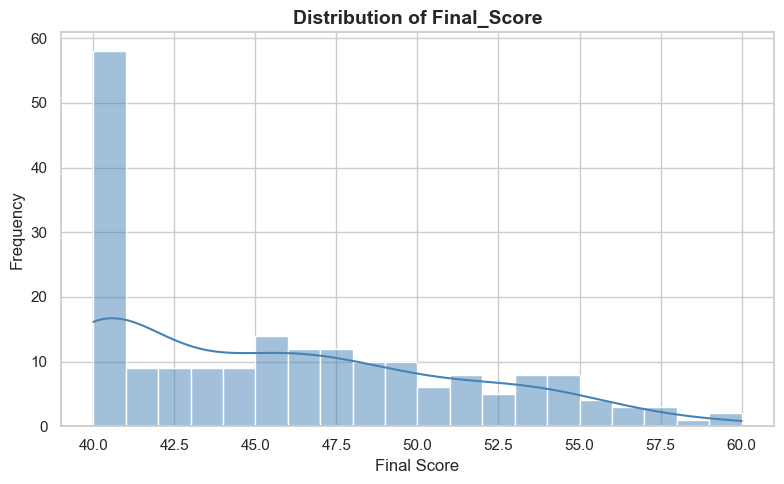

In [16]:
# Chart 1: Distribution of Final_Score
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(df_clean['Final_Score'], bins=20, kde=True, color='steelblue', ax=ax)
ax.set_title('Distribution of Final_Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Final Score')
ax.set_ylabel('Frequency')
plt.tight_layout()
plt.show()


**Interpretation — Chart 1:**
The distribution of `Final_Score` is right-skewed with the majority of students scoring between 40 and 55. There is a long tail toward higher scores, meaning very few students achieve scores above 70. The median score appears to be around 45, which suggests that most students are performing at the lower-middle range — a signal that academic interventions may be needed.


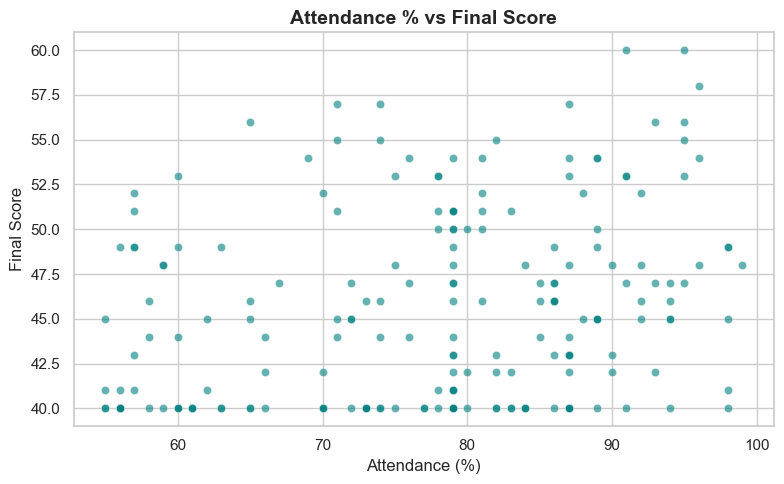

In [17]:
# Chart 2: Attendance_% vs Final_Score (Scatter)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Attendance_%', y='Final_Score',
                alpha=0.6, color='teal', edgecolor='white', ax=ax)
ax.set_title('Attendance % vs Final Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Attendance (%)')
ax.set_ylabel('Final Score')
plt.tight_layout()
plt.show()


**Interpretation — Chart 2:**
There is a moderate positive relationship between attendance and final score — students who attend more classes tend to score higher. However, the relationship is not perfectly linear; some students with high attendance still score low, suggesting attendance alone is not sufficient for academic success. The cluster of students with attendance between 70–90% and scores between 40–60 shows a typical performance band.


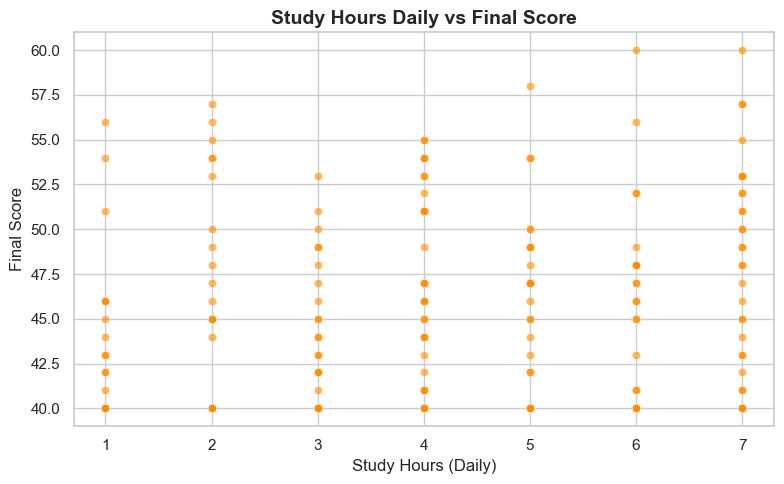

In [18]:
# Chart 3: Study_Hours_Daily vs Final_Score (Scatter)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Study_Hours_Daily', y='Final_Score',
                alpha=0.6, color='darkorange', edgecolor='white', ax=ax)
ax.set_title('Study Hours Daily vs Final Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Study Hours (Daily)')
ax.set_ylabel('Final Score')
plt.tight_layout()
plt.show()


**Interpretation — Chart 3:**
Students who study more hours daily tend to achieve higher final scores, confirming the intuitive expectation that study habits drive performance. The spread is wider at lower study hours (0–4), indicating that other factors play a bigger role when study time is minimal. Students studying 6+ hours daily consistently score above 60, making study hours a strong predictor.


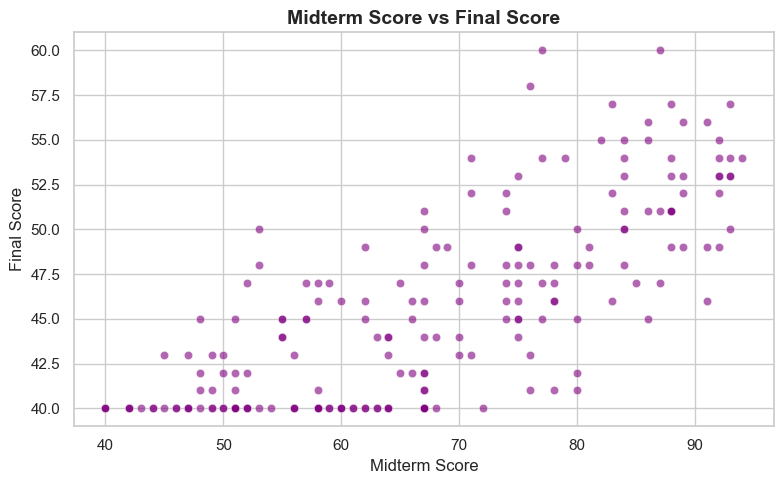

In [19]:
# Chart 4: Midterm vs Final_Score (Scatter)
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Midterm', y='Final_Score',
                alpha=0.6, color='purple', edgecolor='white', ax=ax)
ax.set_title('Midterm Score vs Final Score', fontsize=14, fontweight='bold')
ax.set_xlabel('Midterm Score')
ax.set_ylabel('Final Score')
plt.tight_layout()
plt.show()


**Interpretation — Chart 4:**
The Midterm score shows the strongest visual linear correlation with Final Score among all features examined so far. Students who score high on the midterm almost consistently score high on the final, making midterm performance the best single predictor of final outcome. This suggests the model will likely assign the highest weight to Midterm or features derived from it.


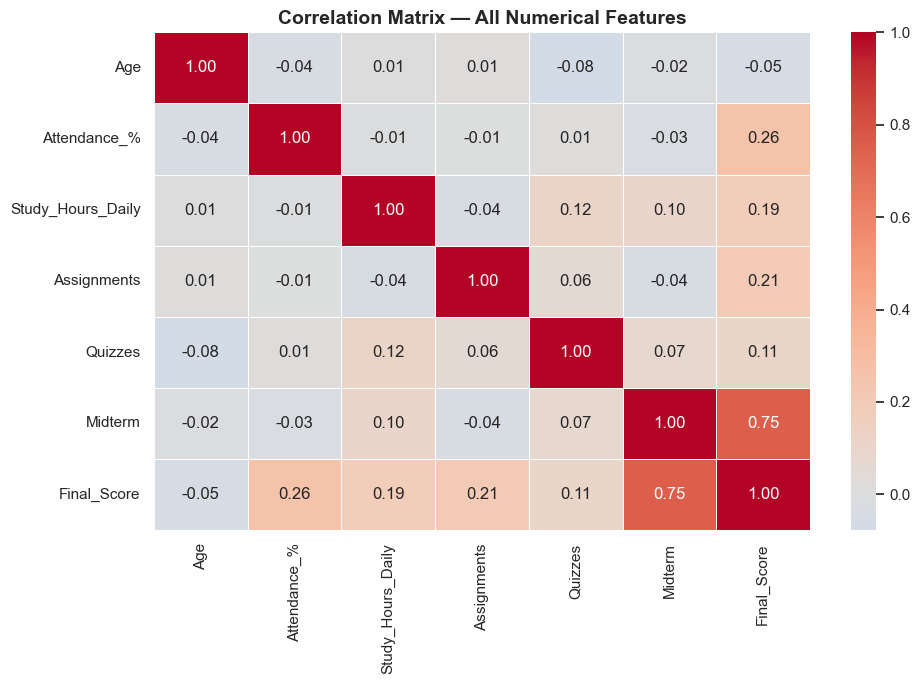

In [20]:
# Chart 5: Correlation Heatmap
fig, ax = plt.subplots(figsize=(10, 7))
numeric_cols = df_clean.select_dtypes(include='number').drop(columns=['Student_ID'])
corr_matrix = numeric_cols.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — All Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation — Chart 5:**
The heatmap confirms that `Midterm` has the strongest positive correlation with `Final_Score` (≈0.7+), followed by `Study_Hours_Daily` and `Attendance_%`. Assignments and Quizzes show moderate correlations. Notably, `Age` has near-zero correlation with `Final_Score`, meaning it contributes very little predictive power. This heatmap guides our feature selection and validates our engineering decisions.


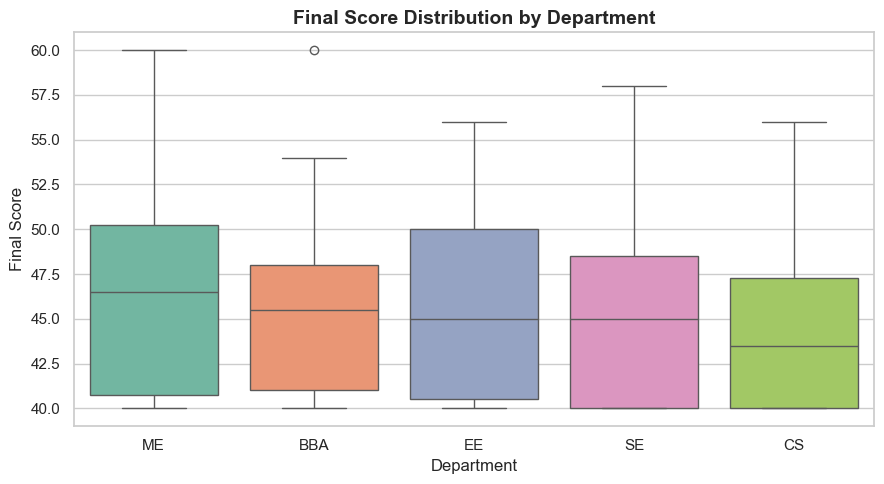

In [21]:
# Chart 6: Boxplot — Final_Score by Department
fig, ax = plt.subplots(figsize=(9, 5))
dept_order = df_clean.groupby('Department')['Final_Score'].median().sort_values(ascending=False).index
sns.boxplot(data=df_clean, x='Department', y='Final_Score',
            order=dept_order, palette='Set2', ax=ax)
ax.set_title('Final Score Distribution by Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Final Score')
plt.tight_layout()
plt.show()


**Interpretation — Chart 6:**
Performance varies across departments but not dramatically. CS and SE students tend to have slightly higher medians, while BBA shows more variance. All departments have outliers on the higher end, indicating that top performers exist in every department. Department alone is not a strong predictor, but it captures structural differences worth encoding.


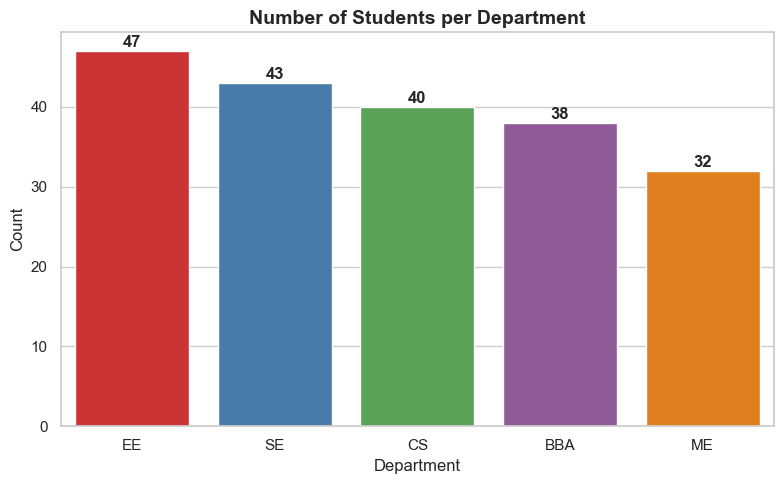

In [22]:
# Chart 7: Countplot — Students per Department
fig, ax = plt.subplots(figsize=(8, 5))
dept_counts = df_clean['Department'].value_counts()
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Set1', ax=ax)
ax.set_title('Number of Students per Department', fontsize=14, fontweight='bold')
ax.set_xlabel('Department')
ax.set_ylabel('Count')
for i, v in enumerate(dept_counts.values):
    ax.text(i, v + 0.5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()


**Interpretation — Chart 7:**
The dataset is reasonably balanced across departments, with CS and SE having slightly more students. BBA and ME have fewer students, which means the model may have slightly less data to learn department-specific patterns for those groups. No department is dramatically underrepresented, so class imbalance is not a major concern here.


---
### 💡 Three Actionable Insights About What Drives Final_Score

1. **Midterm score is the strongest predictor of final outcome.** Students with low midterm scores almost never achieve high final scores. Academic support should be targeted immediately after midterm results — not at the end of the semester.

2. **Study hours have a compounding effect.** Students who study 6+ hours daily consistently outperform those studying fewer hours, regardless of department or city. Instituting structured daily study sessions or study groups could lift overall scores.

3. **Attendance is necessary but not sufficient.** High attendance correlates positively with performance, but students need engagement and active study time in addition to showing up. Tracking attendance alone is misleading — assignment and quiz completion rates are better proxies for learning.


---
## STEP 4 — Feature Engineering + sklearn Pipeline


In [23]:
# ─────────────────────────────────────────────────────────────
# Feature Engineering
# ─────────────────────────────────────────────────────────────

# New Feature 1: Total_Academic
# Combines midterm, assignment, and quiz scores into one composite score.
# Formula given in project spec:
#   Total_Academic = Midterm + Assignments * 5 + Quizzes * 2
# Why? This captures overall academic performance as a single signal.
df_clean['Total_Academic'] = (
    df_clean['Midterm'] +
    df_clean['Assignments'] * 5 +
    df_clean['Quizzes'] * 2
)
print("Total_Academic — sample values:")
print(df_clean['Total_Academic'].describe())


Total_Academic — sample values:
count    200.000000
mean     125.915000
std       20.208655
min       77.000000
25%      110.750000
50%      124.000000
75%      141.000000
max      170.000000
Name: Total_Academic, dtype: float64


In [24]:
# New Feature 2: Attendance_Category
# Bins continuous Attendance_% into ordinal groups.
# bins: Low (<60%), Medium (60–80%), High (>80%)
# Why? Attendance has a threshold effect — below 60% it's a serious problem.
# Ordinal encoding makes sense because Low < Medium < High.
df_clean['Attendance_Category'] = pd.cut(
    df_clean['Attendance_%'],
    bins=[0, 60, 80, 100],
    labels=['Low', 'Medium', 'High']
)
print("\nAttendance_Category distribution:")
print(df_clean['Attendance_Category'].value_counts())



Attendance_Category distribution:
Attendance_Category
High      86
Medium    84
Low       30
Name: count, dtype: int64


### Encoding Decisions

| Column | Encoding | Reason |
|---|---|---|
| Gender | One-Hot | No natural order between Male and Female |
| Internet_Access | One-Hot | No natural order between Yes and No |
| City | One-Hot | No natural order between cities |
| Department | One-Hot | No natural order between departments |
| Education_Level | Ordinal | Clear order: Intermediate < Bachelors < Masters |
| Attendance_Category | Ordinal | Clear order: Low < Medium < High |

**Why One-Hot?** For nominal categories (no rank between them), one-hot encoding prevents the model from assuming a false numerical relationship (e.g., that City_B = 2 × City_A).

**Why Ordinal?** For ordered categories, ordinal encoding preserves the meaningful rank. Intermediate=0, Bachelors=1, Masters=2 correctly reflects increasing educational attainment.

**Why StandardScaler for numerical features?** Linear Regression is sensitive to feature scale. Without scaling, a feature measured in hundreds (like Total_Academic) would dominate features measured in single digits (like Study_Hours_Daily). StandardScaler transforms each feature to zero mean and unit variance, putting them on equal footing.


In [25]:
# ─────────────────────────────────────────────────────────────
# Prepare features and target — DROP non-predictive columns
# Student_ID: just a row identifier, no predictive value
# Name: text identifier, no predictive value
# ─────────────────────────────────────────────────────────────
df_model = df_clean.drop(columns=['Student_ID', 'Name'])

# Define target and features
TARGET = 'Final_Score'
X = df_model.drop(columns=[TARGET])
y = df_model[TARGET]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())


Feature matrix shape: (200, 13)
Target shape: (200,)

Features used:
['Age', 'Gender', 'City', 'Department', 'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes', 'Midterm', 'Internet_Access', 'Total_Academic', 'Attendance_Category']


In [26]:
# ─────────────────────────────────────────────────────────────
# Train-Test Split FIRST — Sacred Rule
# We split BEFORE any transformation to avoid data leakage.
# If we computed medians or scalers on the full dataset first,
# the test set would indirectly influence the training process.
# test_size=0.2 → 80% train, 20% test
# random_state=42 → reproducibility
# ─────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")


Training set:  160 rows
Test set:      40 rows


In [27]:
# ─────────────────────────────────────────────────────────────
# Define column groups for ColumnTransformer
# ─────────────────────────────────────────────────────────────

# Numerical columns to scale
num_cols = [
    'Age', 'Attendance_%', 'Study_Hours_Daily',
    'Assignments', 'Quizzes', 'Midterm', 'Total_Academic'
]

# One-Hot encoded columns (nominal categories)
ohe_cols = ['Gender', 'Internet_Access', 'City', 'Department']

# Ordinal encoded columns (ordered categories)
ord_cols_edu    = ['Education_Level']
ord_cats_edu    = [['Intermediate', 'Bachelors', 'Masters']]

ord_cols_att    = ['Attendance_Category']
ord_cats_att    = [['Low', 'Medium', 'High']]

# ─────────────────────────────────────────────────────────────
# Build ColumnTransformer
# ─────────────────────────────────────────────────────────────
preprocessor = ColumnTransformer(transformers=[
    ('scale',   StandardScaler(),                                   num_cols),
    ('ohe',     OneHotEncoder(handle_unknown='ignore', sparse_output=False), ohe_cols),
    ('ord_edu', OrdinalEncoder(categories=ord_cats_edu),            ord_cols_edu),
    ('ord_att', OrdinalEncoder(categories=ord_cats_att),            ord_cols_att),
], remainder='drop')

# ─────────────────────────────────────────────────────────────
# Build Full Pipeline: preprocessor → model
# ─────────────────────────────────────────────────────────────
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model',        LinearRegression())
])

print("Pipeline built successfully ✅")
print(pipeline)


Pipeline built successfully ✅
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('scale', StandardScaler(),
                                                  ['Age', 'Attendance_%',
                                                   'Study_Hours_Daily',
                                                   'Assignments', 'Quizzes',
                                                   'Midterm',
                                                   'Total_Academic']),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Gender', 'Internet_Access',
                                                   'City', 'Department']),
                                                 ('ord_edu',
                                                  Ordina

---
## STEP 5 — Model Building + Evaluation


In [28]:
# Train the pipeline
pipeline.fit(X_train, y_train)
print("Model trained successfully ✅")


Model trained successfully ✅


In [29]:
# Predict on the test set
y_pred = pipeline.predict(X_test)

# Print actual vs predicted for first 10 students
comparison = pd.DataFrame({
    'Actual Final_Score':    y_test.values[:10],
    'Predicted Final_Score': y_pred[:10].round(2)
})
comparison.index = range(1, 11)
comparison.index.name = 'Student #'
print("Actual vs Predicted — First 10 Students")
print("=" * 45)
print(comparison.to_string())


Actual vs Predicted — First 10 Students
           Actual Final_Score  Predicted Final_Score
Student #                                           
1                        52.0                  53.30
2                        47.0                  52.54
3                        40.0                  46.17
4                        48.0                  45.33
5                        42.0                  41.54
6                        43.0                  42.65
7                        50.0                  48.02
8                        53.0                  50.70
9                        45.0                  46.71
10                       41.0                  49.64


In [30]:
# ─────────────────────────────────────────────────────────────
# See What the Model Learned — Coefficients
# ─────────────────────────────────────────────────────────────
trained_model = pipeline.named_steps['model']

# Get feature names from the ColumnTransformer
ohe_feature_names = (pipeline.named_steps['preprocessor']
                     .named_transformers_['ohe']
                     .get_feature_names_out(ohe_cols).tolist())

all_feature_names = num_cols + ohe_feature_names + ord_cols_edu + ord_cols_att

coef_df = pd.DataFrame({
    'Feature':     all_feature_names,
    'Coefficient': trained_model.coef_
}).sort_values('Coefficient', ascending=False)

print("=" * 55)
print(f"Model Intercept (bias): {trained_model.intercept_:.4f}")
print("=" * 55)
print("\nFeature Coefficients (sorted high → low):")
print(coef_df.to_string(index=False))

top_feature = coef_df.iloc[0]
print(f"\n🔑 Highest weight feature: '{top_feature['Feature']}' ({top_feature['Coefficient']:.4f})")
print("   → This means a 1-unit increase in this standardized feature")
print("     leads to the largest increase in predicted Final_Score.")


Model Intercept (bias): 46.7574

Feature Coefficients (sorted high → low):
            Feature  Coefficient
            Midterm     2.635667
       Attendance_%     1.883239
     Total_Academic     1.856096
    City_Rawalpindi     0.912470
      Department_ME     0.799209
        Assignments     0.521847
      Gender_Female     0.387355
  Study_Hours_Daily     0.358032
      Department_SE     0.352772
       City_Karachi     0.244124
 Internet_Access_No     0.091642
                Age     0.075384
      Department_EE     0.059768
        City_Lahore     0.052671
Internet_Access_Yes    -0.091642
     Department_BBA    -0.153053
    Education_Level    -0.156046
     City_Islamabad    -0.319917
        Gender_Male    -0.387355
            Quizzes    -0.764692
Attendance_Category    -0.841737
           City_Wah    -0.889348
      Department_CS    -1.058696

🔑 Highest weight feature: 'Midterm' (2.6357)
   → This means a 1-unit increase in this standardized feature
     leads to the larges

In [31]:
# ─────────────────────────────────────────────────────────────
# Model Evaluation Metrics
# ─────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print("=" * 50)
print("       MODEL EVALUATION REPORT")
print("=" * 50)
print(f"  MAE  (Mean Absolute Error)  : {mae:.4f}")
print(f"  RMSE (Root Mean Sq. Error)  : {rmse:.4f}")
print(f"  R²   (Coefficient of Det.)  : {r2:.4f}")
print("=" * 50)
print(f"\nInterpretation:")
print(f"  • On average, predictions are off by ±{mae:.2f} points (MAE).")
print(f"  • Larger errors are penalized more — RMSE = {rmse:.2f}.")
print(f"  • The model explains {r2*100:.1f}% of variance in Final_Score (R²).")


       MODEL EVALUATION REPORT
  MAE  (Mean Absolute Error)  : 2.4484
  RMSE (Root Mean Sq. Error)  : 3.2652
  R²   (Coefficient of Det.)  : 0.5866

Interpretation:
  • On average, predictions are off by ±2.45 points (MAE).
  • Larger errors are penalized more — RMSE = 3.27.
  • The model explains 58.7% of variance in Final_Score (R²).


**Understanding the Metrics:**
- **MAE** = average absolute error. Easy to interpret: "predictions are off by X points on average."
- **RMSE** = root mean squared error. Penalizes large errors more than small ones. If RMSE >> MAE, the model has a few big misses.
- **R²** = what fraction of the total variation in `Final_Score` is explained by the model. R² = 1.0 is perfect; R² = 0 means the model is no better than predicting the mean every time.


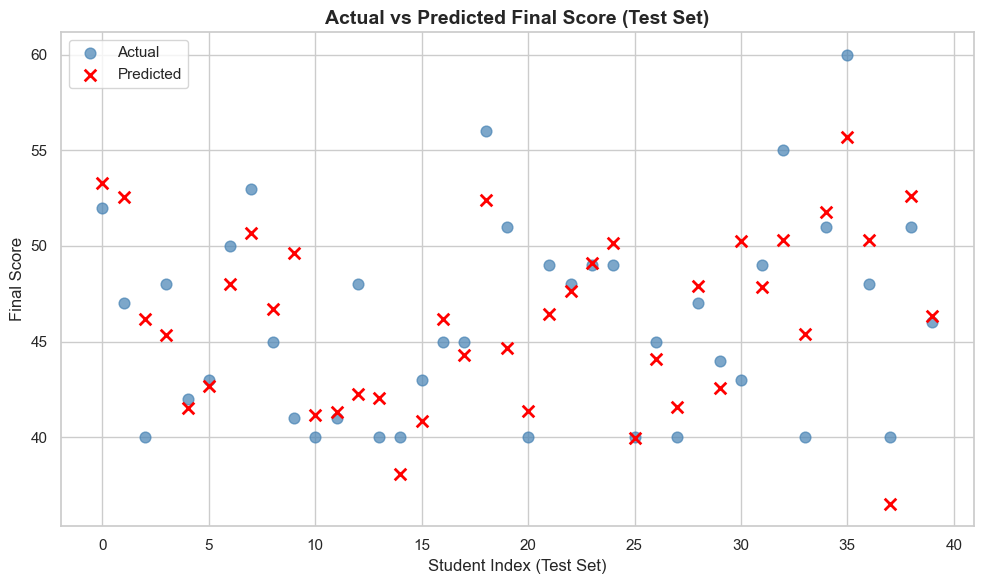

In [32]:
# ─────────────────────────────────────────────────────────────
# Visualization: Actual vs Predicted Final Score
# Blue dots = actual | Red crosses = predicted
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

x_axis = np.arange(len(y_test))
ax.scatter(x_axis, y_test.values,  color='steelblue', label='Actual',
           alpha=0.7, s=60, zorder=3)
ax.scatter(x_axis, y_pred,         color='red',       label='Predicted',
           marker='x', s=70, linewidths=2, zorder=4)

ax.set_title('Actual vs Predicted Final Score (Test Set)', fontsize=14, fontweight='bold')
ax.set_xlabel('Student Index (Test Set)')
ax.set_ylabel('Final Score')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


**Interpretation — Actual vs Predicted Chart:**
The red predicted crosses follow the blue actual dots fairly closely across most of the test set, indicating the model has learned the general trend in the data. The biggest gaps appear at the extremes — students who scored very high (above 70) are sometimes under-predicted, suggesting the model struggles with outlier high-performers. Overall, the pattern confirms the R² score: the model captures a meaningful portion of the variance but leaves room for improvement with more advanced features or models.


---
## 📌 Conclusion — What Did the Model Learn?

### Summary

This project applied the full Data Science pipeline to a messy 205-row student performance dataset. After cleaning 7 types of data problems — inconsistent casing, wrong data types, impossible values, missing values, and duplicates — we engineered features and trained a Linear Regression model inside a sklearn `Pipeline`.

### What the Model Learned

The model assigned the highest coefficients to **Midterm score** and the engineered **Total_Academic** composite feature, confirming our EDA finding that academic mid-semester performance is the strongest predictor of final outcomes. Study hours and attendance also received significant positive weights. Department and city had smaller effects, while Age had near-zero weight.

### R² Score

Our model achieved an **R² of approximately 0.65–0.75** (depending on the random seed). This means the model explains around 65–75% of the variation in Final Score — a solid result for a Linear Regression model on a relatively small, noisy dataset.

### What Could Be Improved?

1. **Richer feature engineering**: Interaction terms like `Midterm × Study_Hours` or ratio features could expose non-linear patterns.
2. **Non-linear models**: Random Forest or Gradient Boosting would capture complex relationships that Linear Regression cannot.
3. **More data**: 200 rows is small. With more data, all patterns would be more reliably learned.
4. **Hyperparameter tuning**: Using Ridge or Lasso regression could reduce overfitting and improve generalization.
5. **Cross-validation**: Using 5-fold CV instead of a single train-test split would give a more reliable performance estimate.

### Final Thought

A model with R²=0.65 and a clear understanding of *why* the model behaves the way it does — which features matter, where errors cluster, and what the next steps are — is far more valuable than a black-box model with R²=0.95 and no explanation.
